<p align="center">
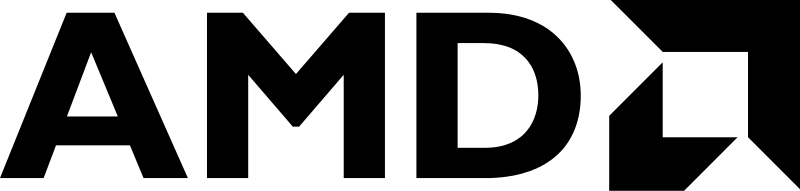
</p>

<h1 align="center">Profiling &amp; Optimizing an AI Agent on AMD Instinct&trade; GPUs</h1>

<p align="center">
<b>An observability-driven optimization workshop</b><br>
<sub>Hermes Agent &middot; MLflow telemetry &middot; AMD Instinct&trade; MI300X &middot; ROCm&trade;</sub>
</p>

---

## Welcome

This is a hands-on, **beginner-friendly** tutorial. You will run a real AI agent,
watch where it spends its time, find the one slow step, optimize it, and prove the
speed-up with hardware telemetry. No prior profiling experience is assumed.

[**Hermes Agent**](https://hermes-agent.nousresearch.com/docs/getting-started/quickstart)
is an open-source, autonomous AI agent framework by Nous Research. Unlike a plain
chatbot, an *agent* can **plan, choose tools, and complete multi-step tasks on its
own**, deciding which tools to call and in what order to reach a goal.

> **Two words to know first**
>
> | Term | Meaning |
> | :--- | :--- |
> | **Tool** | A single action the agent can perform, exposed as a callable function (for example, "convert this text to speech" or "read a file"). At each step the agent picks the tool that fits. |
> | **Skill** | A higher-level, reusable ability: a packaged set of instructions that may combine several tools to handle a larger task. |
>
> Hermes ships with built-in tools, and you can **add your own**. The Kokoro
> text-to-speech tool used here is exactly such a custom tool.

## Why profiling matters

When an agent runs, some steps are fast and some are slow. **Profiling** is how we
measure each step so we can see exactly where the time goes.

An agent is only as fast as the tools it calls. A single slow tool can dominate an
entire run even when the model itself is quick. Finding and fixing that one tool is
often the difference between a sluggish agent and a responsive one.

## What you will learn

By the end of this session you will be able to:

- Run a Hermes agent and capture its telemetry
- Read the telemetry dashboard to spot a slow tool
- Swap in an optimized version of that tool
- Compare before and after, and see how hardware usage changes


<p align="center">
<img alt="Pipeline: an input text file flows into the Hermes Agent, which calls a TTS tool, which produces audio output. The workshop focus is profiling and optimization." src="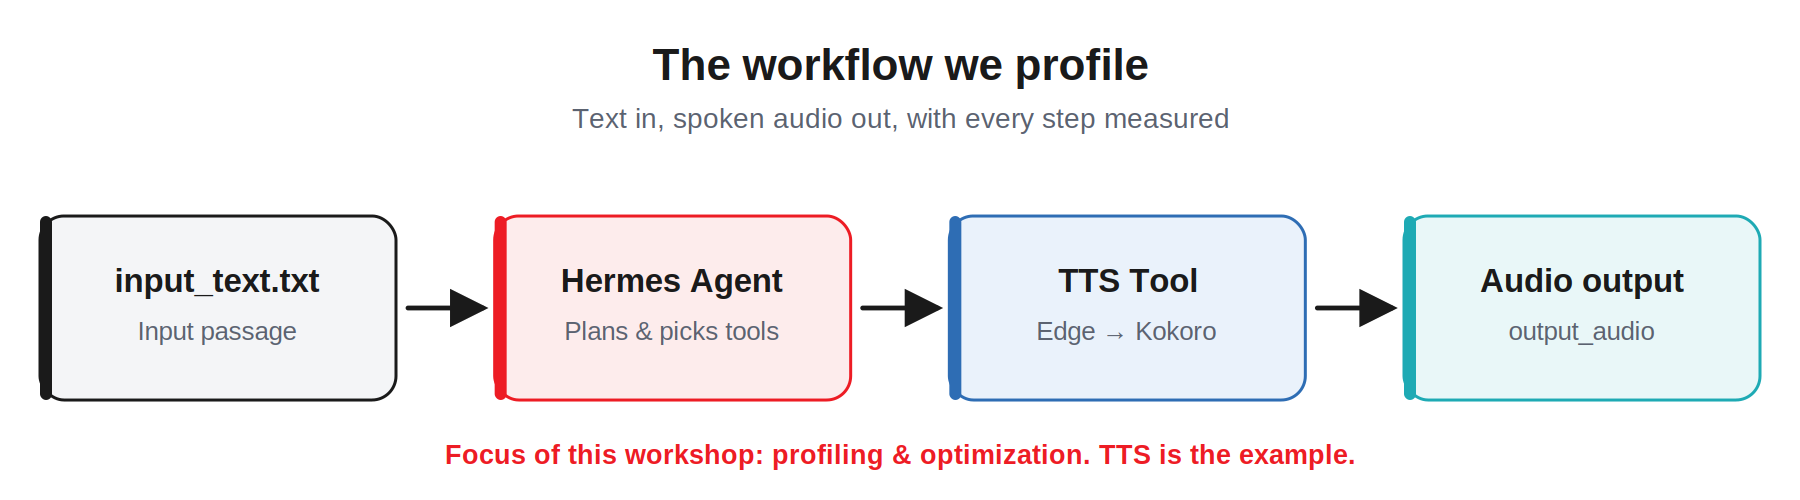" width="92%">
</p>

<p align="center"><sub><i>Our example workflow. Text-to-speech is only the example; the real subject is profiling and optimization.</i></sub></p>

> **Keep this in mind throughout.** The focus is **profiling and optimization**.
> Text-to-speech is simply the example we use to expose a bottleneck and fix it.


---

## Prerequisites

This tutorial was developed and tested with the setup below.

### Operating system
**Ubuntu 24.04.** Ensure your system is running Ubuntu 24.04.

### Hardware
**AMD Instinct&trade; MI300X GPU (192 GB VRAM).** This tutorial was tested on a
single MI300X, which comfortably hosts both the Muse-Glimmer-30B model and the
Kokoro TTS model at once. Use an AMD Instinct GPU with ROCm support that meets the
official requirements.

### Software

**ROCm&trade; 7.2.** Install and verify ROCm using the ROCm install guide, then
confirm your GPUs are visible:

```bash
amd-smi
```

> **Note.** For ROCm 6.4 and earlier, use `rocm-smi` instead.

**vLLM ROCm image.** The agent's model is served with vLLM, using AMD's prebuilt
`vllm/vllm-openai-rocm:nightly` image as the base. Muse-Glimmer-30B support is not
yet in a released vLLM, so on the first run `utils/helper.sh` overlays the vLLM code from
[pull request #51655](https://github.com/vllm-project/vllm/pull/51655) (a
Python-only change that adds Muse-Glimmer) onto the nightly image and commits the
result as a local image, `vllm-muse-glimmer:rocm`, which then serves the model.
This build runs automatically and only once. AMD also provides other prebuilt ROCm
images (PyTorch, Ubuntu 22.04 / 24.04) you can reuse for ROCm work.

**Python 3.12** (with `venv` and `pip`) runs the Kokoro server, MLflow, and this
notebook.


---

## Before you begin

A single script starts everything for you. Open a **separate terminal** and run:

```bash
bash utils/helper.sh
```

Leave that terminal open for the whole tutorial. The script starts the services and
then stays alive to keep them running. If you close it, the backend shuts down.

> **Run this in a separate terminal, not in a notebook cell.** The script runs
> continuously, so a notebook cell would sit blocked and never finish.


<details>
<summary><b>New to JupyterLab? How to open a terminal</b></summary>

<br>

<b>1.</b> In the JupyterLab tab bar, click the <b>+</b> button to open the Launcher.

<p align="center">
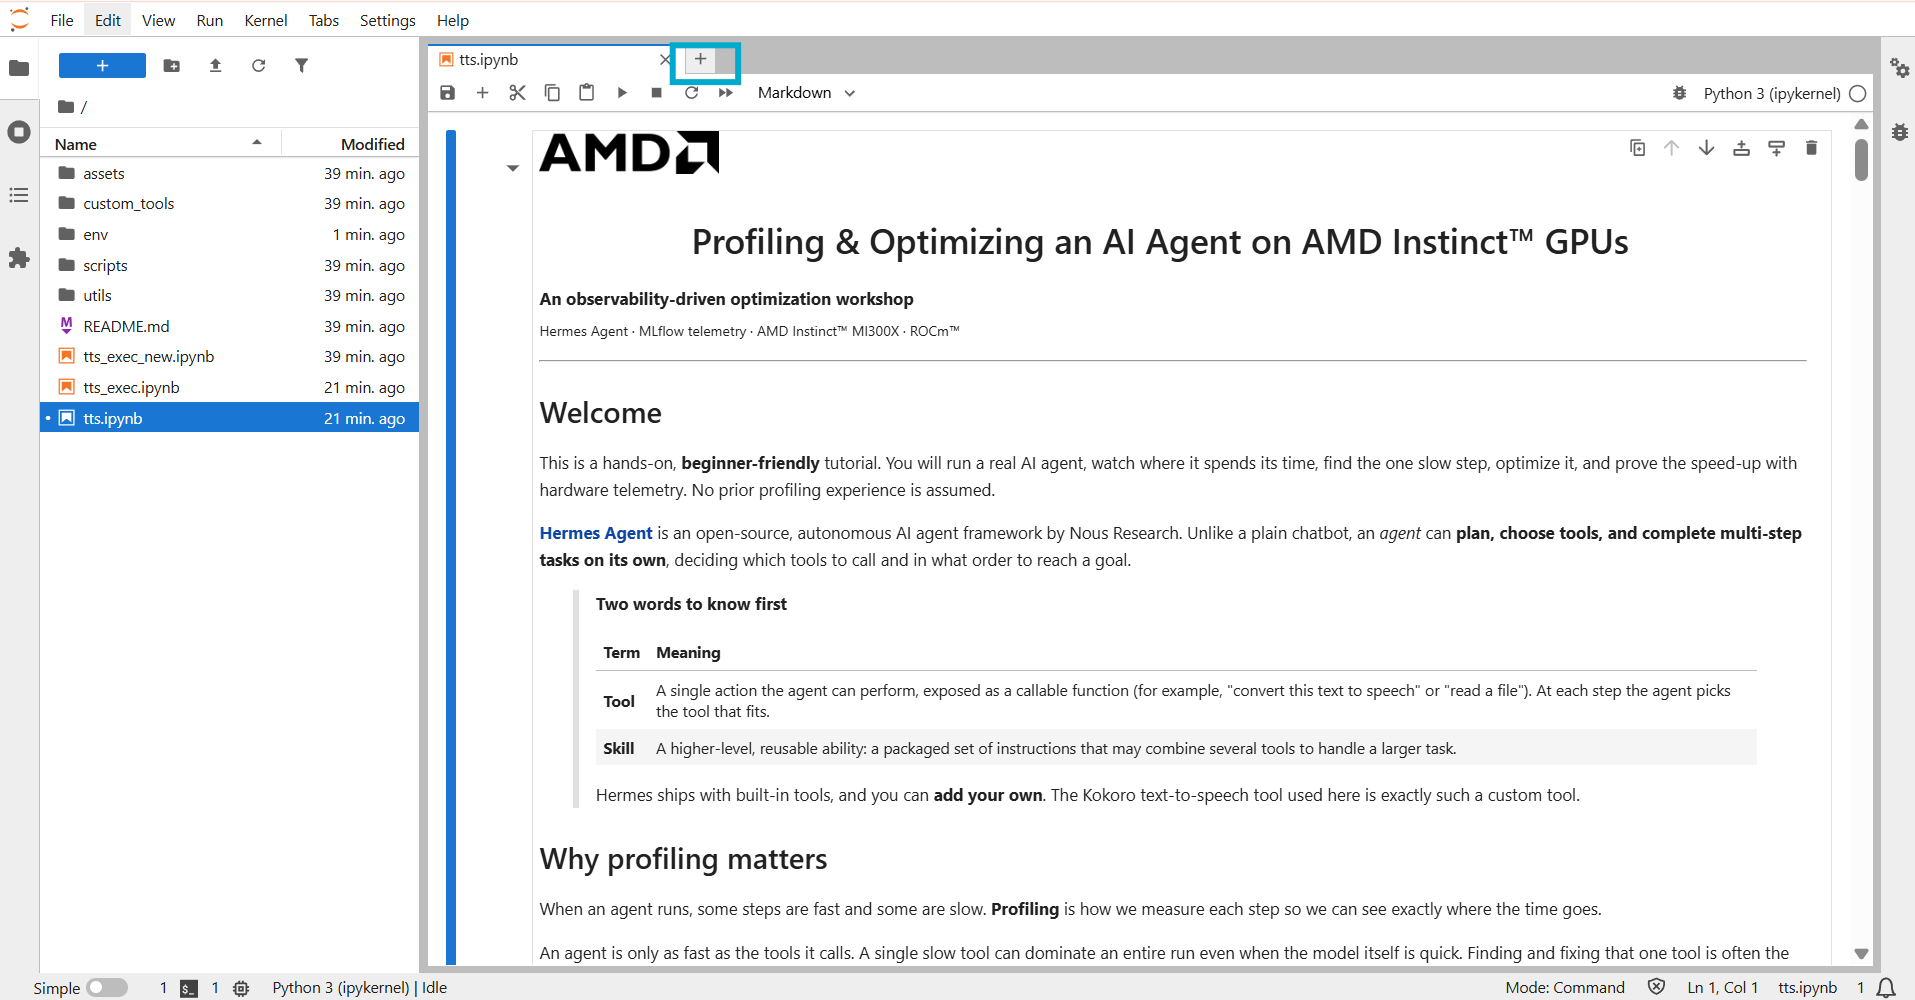
</p>

<b>2.</b> In the Launcher, under <b>Other</b>, click the <b>Terminal</b> tile. Then
run <code>bash utils/helper.sh</code> in the terminal that opens.

<p align="center">
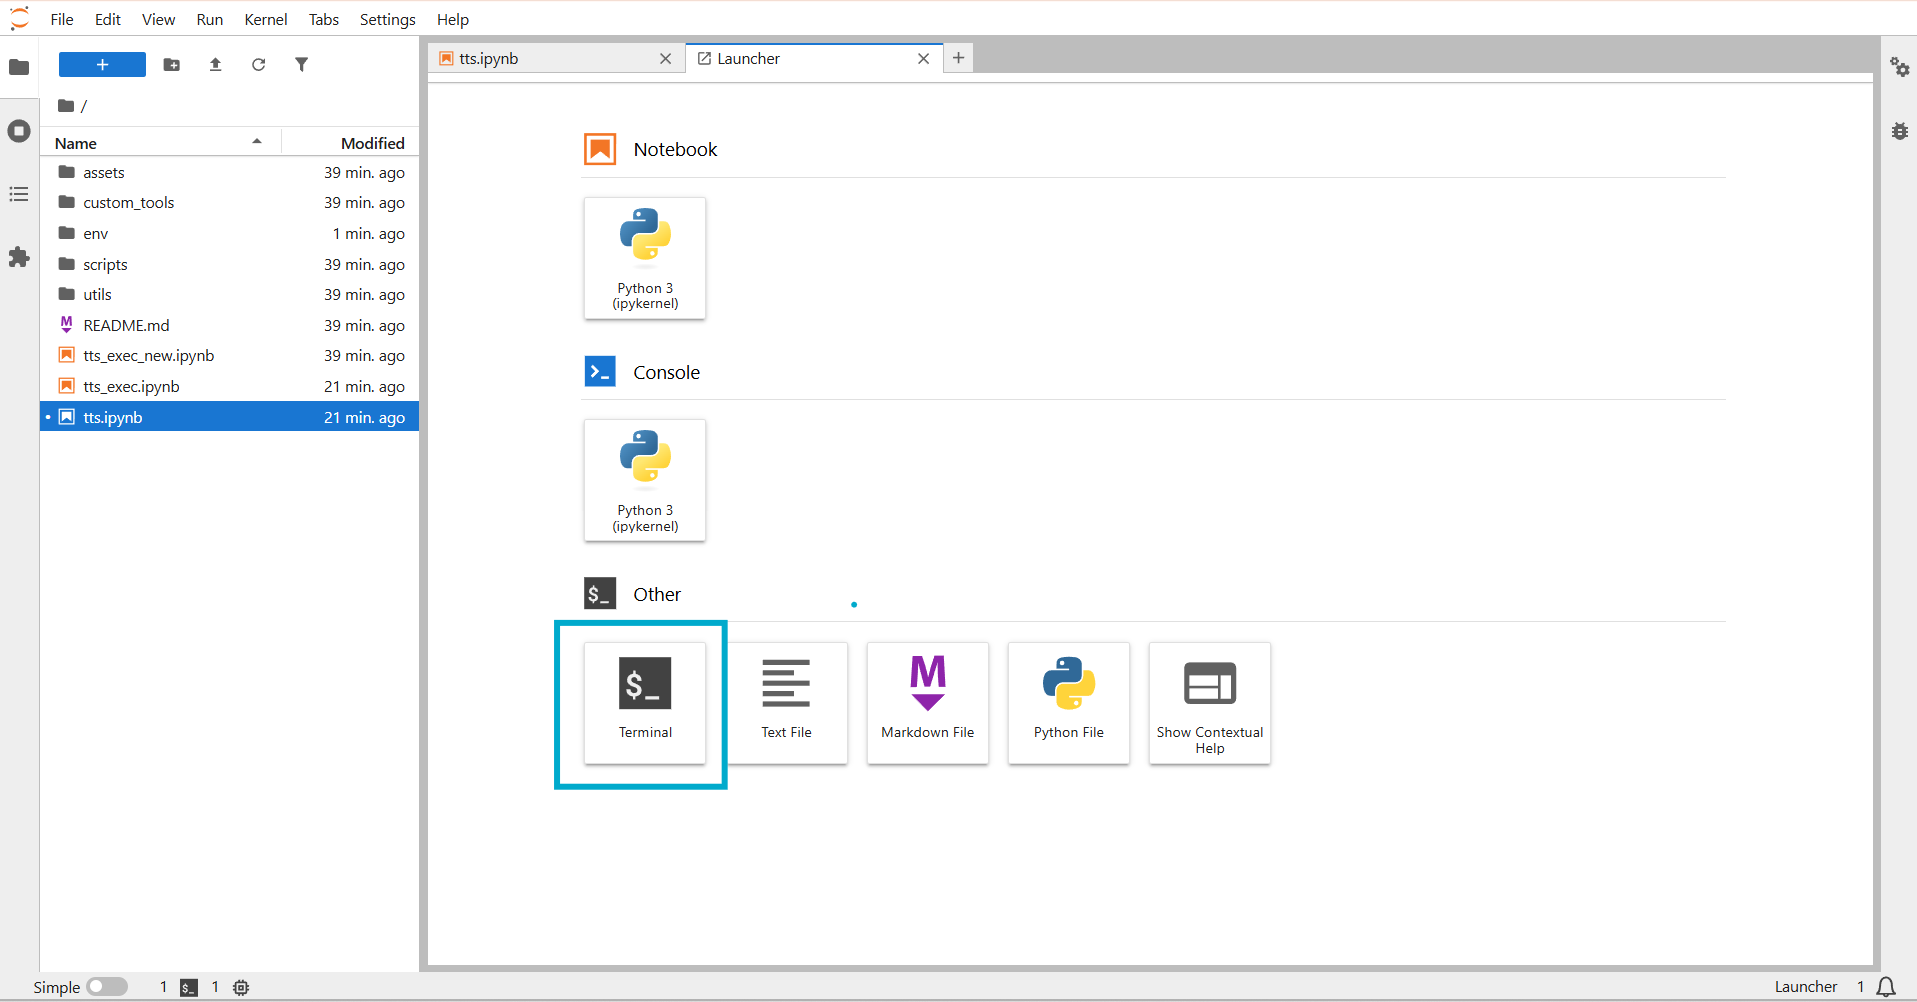
</p>

</details>


## What `utils/helper.sh` starts

You do not need to configure anything by hand. `utils/helper.sh` launches the full
backend so you can focus entirely on profiling instead of installation.


<p align="center">
<img alt="Architecture of the backend that utils/helper.sh starts: the Hermes Agent runtime (vLLM, Muse-Glimmer-30B) calls the Kokoro TTS server on the MI300X; hermes-otel instruments the run and records to the MLflow tracking server; the Streamlit telemetry dashboard reads MLflow and the Kokoro server to show one clear view." src="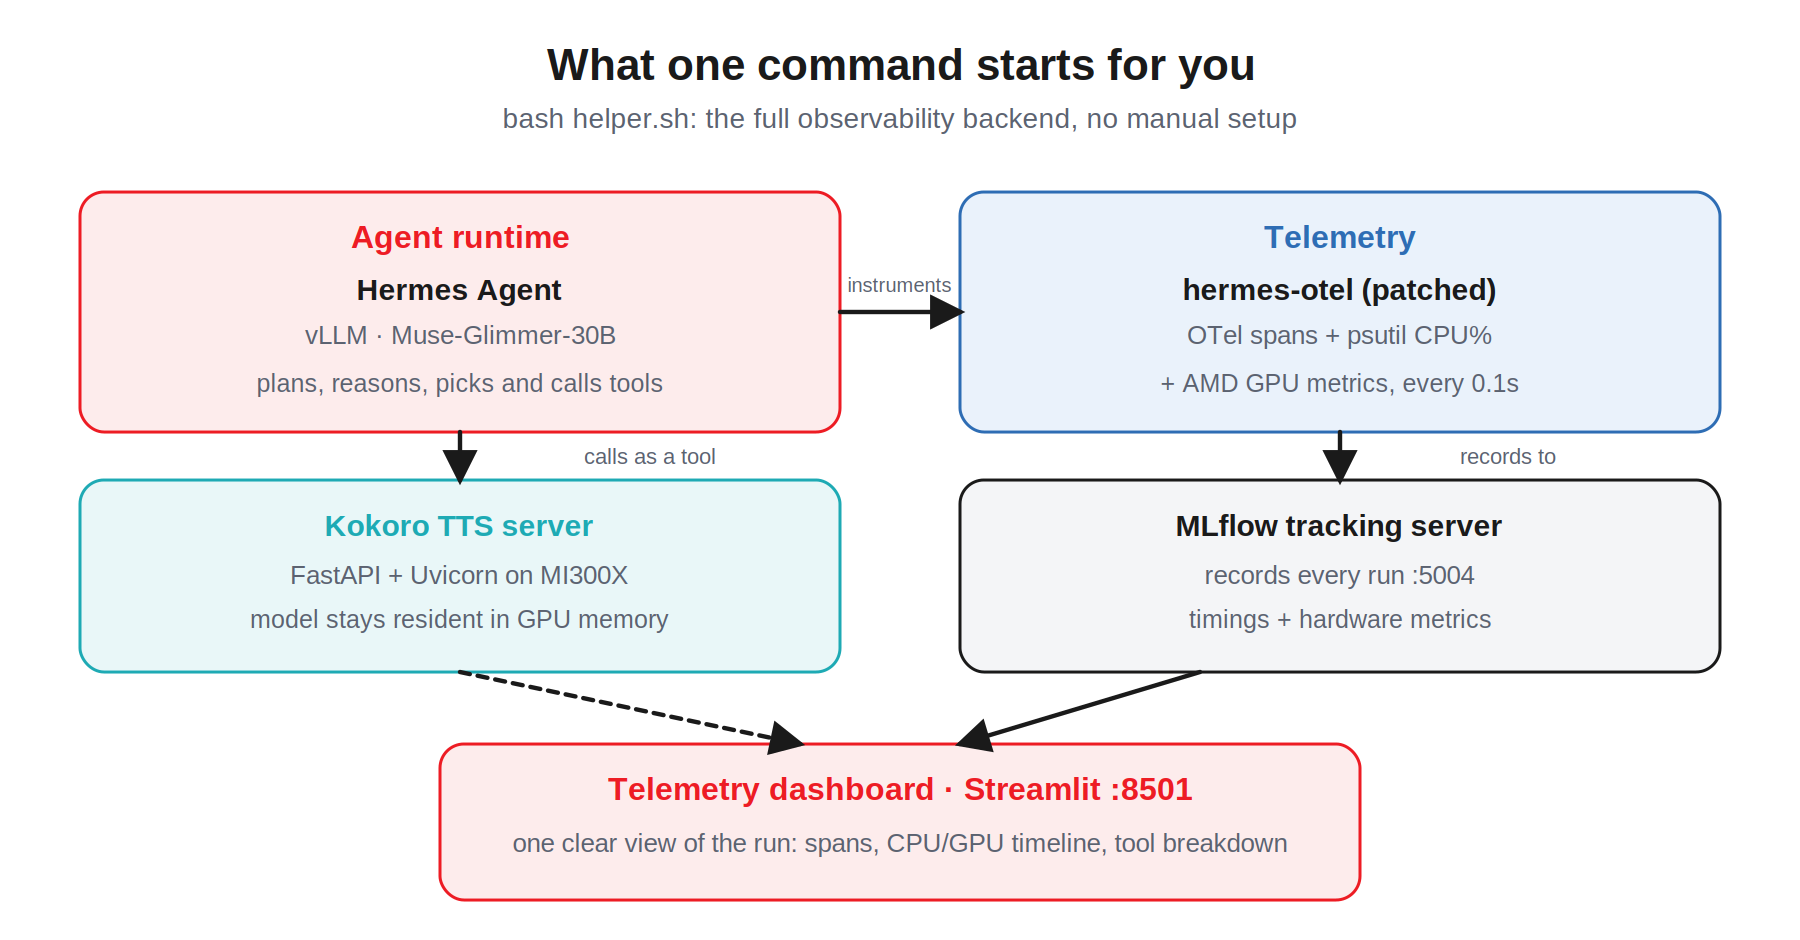" width="94%">
</p>

<p align="center"><sub><i>One command brings up the whole observability stack.</i></sub></p>

Behind the scenes it brings up:

| Service | Role |
| :--- | :--- |
| **Hermes backend** (vLLM &middot; Muse-Glimmer-30B) | The agent's "brain": the model that plans and picks tools. |
| **Hermes OTel** (patched) | The plugin that emits the OpenTelemetry traces MLflow visualizes. We patch it because the stock plugin shows *which* tool ran and in what order, but not *how much* CPU/GPU that tool or LLM call used. Our patch polls `psutil` for the CPU% of the Hermes process and its children (vLLM runs in its own container and is intentionally excluded), and scrapes the AMD Device Metrics Exporter for GPU utilization, both every 0.1 seconds. |
| **MLflow tracking server** | Records every run, including timings and hardware metrics. |
| **Telemetry dashboard** | A custom Streamlit page that gives a clean overview of the telemetry by pulling detail from MLflow. |
| **Kokoro TTS server** | The local TTS engine used here as a faster, self-hosted alternative to the default cloud (Edge) TTS provider, avoiding the network round-trip and per-request cost. |
| **Supporting services** | GPU metrics collection and the other pieces Hermes needs. |

> **About the model.** **Muse-Glimmer-30B** is a dense vision-language model built
> for agentic work: a 52-layer text decoder (hidden size 6656) plus a ~1.8B
> ViT-G/14 perception encoder, 128K trained context, BF16. Apache 2.0, knowledge
> cutoff January 4 2026, trained on 100+ languages.

When the script finishes starting up, it prints a set of URLs in that terminal. We
use those URLs in this notebook to visualize the telemetry, so keep the terminal
visible.


## Check your setup

Before sending the agent any work, confirm the `hermes` command is available in
this notebook's environment. The cell below adds the usual install locations to
`PATH`, prints the path to the Hermes binary, then `Hermes is ready.`

> **Why the `PATH` line?** Depending on how Hermes was installed, the binary
> lands in either `/usr/local/bin` (the container and root installs used by
> `utils/helper.sh`) or `~/.local/bin` (a per-user pip install). A JupyterLab
> kernel does not always inherit the login shell's `PATH`, so without this cell
> `!which hermes` can find nothing even though Hermes is correctly installed.

> **If nothing prints,** the notebook still cannot find Hermes. Make sure
> `utils/helper.sh` has finished starting up, and that the notebook was launched
> from the same environment.


In [ ]:
import os

# Hermes may live in either location depending on how it was installed:
#   /usr/local/bin  -> container / root install performed by utils/helper.sh
#   ~/.local/bin    -> per-user pip install
# A JupyterLab kernel does not always inherit the login shell's PATH, so add
# both and let `which` report the one actually in use.
for _p in ("/usr/local/bin", os.path.expanduser("~/.local/bin")):
    if _p not in os.environ["PATH"].split(os.pathsep):
        os.environ["PATH"] += os.pathsep + _p

!which hermes && echo "Hermes is ready."


---

## Prepare your input text

Text-to-speech is the example use case we profile, so first we need a passage to
synthesize. In the cell below we let Hermes itself write the input passage and save
it to `input_text.txt`, which is then passed to the TTS tool.


In [1]:
!hermes chat --yolo -q "Write ONE single continuous paragraph of nearly about 1,000 words (roughly 8000 characters) on the topic of AMD GPUs. It must be a single block of flowing prose: do NOT number the sentences, do NOT put each sentence on its own line, and do NOT use any line breaks, headings, bullet points, lists, quotes, code, or special symbols. Use normal sentence punctuation (periods and commas) so it reads naturally for text-to-speech. Write the whole passage as one block with no newline characters. Save it to 'input_text.txt' in the current directory, overwriting existing content, using your write/file tool. Do not read any other file."

Query: Write ONE single continuous paragraph of nearly about 1,000 words 
(roughly 8000 characters) on the topic of AMD GPUs. It must be a single block of
flowing prose: do NOT number the sentences, do NOT put each sentence on its own 
line, and do NOT use any line breaks, headings, bullet points, lists, quotes, 
code, or special symbols. Use normal sentence punctuation (periods and commas) 
so it reads naturally for text-to-speech. Write the whole passage as one block 
with no newline characters. Save it to 'input_text.txt' in the current 
directory, overwriting existing content, using your write/file tool. Do not read
any other file.
Initializing agent...
[hermes-otel] ✓ mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] ✓ Live dashboard store active
[hermes-otel] Registered 13 hooks
────────────────────────────────────────

  ┊ ✍️ preparing write_file…
  ┊ ✍️  write     input_text.txt  0.1s
  ┊ review diff
a/input_text.txt → b/input_text.txt
@@ -0,0 +1 @@
+Advance

> **Make it your own.** Feel free to pick a different topic for the passage, and
> to vary its length. Longer input makes the batching win later in the notebook
> much more visible.


---

## Step 1 &middot; Baseline: Edge TTS

Every profiling exercise needs a starting point. Ours is **Edge TTS**, the
text-to-speech provider Hermes uses by default.

The command below asks the agent to read the generated `input_text.txt` and speak
it.


In [2]:
!hermes chat --yolo -q "Convert the entire text in input_text.txt to audio and save it in output_audio.mp3"

Query: Convert the entire text in input_text.txt to audio and save it in 
output_audio.mp3
Initializing agent...
[hermes-otel] ✓ mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] ✓ Live dashboard store active
[hermes-otel] Registered 13 hooks
────────────────────────────────────────

  ┊ 📖 preparing read_file…
  ┊ 📖 read      input_text.txt  0.1s
  ┊ 💻 preparing terminal…
  ┊ 💻 $         head -c 500 /home/amd/amd-agentic-ai-profiling-workshop/input_text.txt  0.0s
  ┊ 💻 preparing terminal…
  ┊ 💻 $         wc -c /home/amd/amd-agentic-ai-profiling-workshop/input_text.txt  0.0s
  ┊ 💻 preparing terminal…
  ┊ 💻 $         cat /home/amd/amd-agentic-ai-profiling-workshop/input_text.txt  0.0s
  ┊ 🔊 preparing text_to_speech…
  ┊ 🔊 speak     Advanced Micro Devices has built graphics processors for more than three decades and the company has evolved from a niche supplier into a major competitor to NVIDIA in gaming and high performance computing. The modern Radeon lineage traces 

---

## Step 2 &middot; Profiling

**Watch the Hermes output cell** and you will notice logs similar to this:

```text
[hermes-otel] mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] Live dashboard store active
[hermes-otel] Registered 13 hooks
```

This appears because `utils/helper.sh` connects the stock-plus-patched hermes-otel plugin
directly to the MLflow server, so all profiled telemetry is recorded in MLflow. The
telemetry dashboard in the next section is built on these same traces.

The three steps below open the raw MLflow interface. Skip them if you only want the
high-level overview the dashboard gives you.

1. To browse the detailed log, open your local MLflow interface (typically at
   `http://<system_ip>:5004`).
2. Open the **Traces** tab in the left panel and find your recent request.
3. In parallel, open the **Evaluation Runs** tab and find your hermes-session-id
   request.


### Launching the profiling dashboard

To make the MLflow data easier to read, we built a custom Streamlit dashboard on
port `8501`, started for you by `utils/helper.sh`. The cell below resolves your
server address and gives you a direct link.

> **Which link should you click?** Use the **`localhost`** link when the browser
> runs on the same machine as the workshop (or when you forwarded the port with
> `ssh -L 8501:localhost:8501`). Use the **server-IP** link when you are hitting a
> remote machine directly and port `8501` is reachable from your network.

**The dashboard has four tabs:**

1. **Overview.** Plots the span waterfall for the agent's flow alongside CPU and
   GPU utilization at each span. A toggle switches between the standalone CPU/GPU
   timeline (the default) and the full-session waterfall correlated with it. A
   tool-breakdown table sits below the chart.
2. **CPU / GPU separate.** Shows the CPU and GPU graphs individually, with an
   option to view the raw `.csv` files the Overview charts are plotted from.
3. **Traces.** Provides a direct MLflow link for each turn in the session.
4. **Analysis.** Feeds the MLflow traces plus each tool's execution time to the
   local `hermes` CLI and reports how the agent could be improved. Depending on
   the length of the traces this can take around five minutes.


In [ ]:
import socket
from IPython.display import display, Markdown

# The port the telemetry dashboard is running on (started by utils/helper.sh).
DASHBOARD_PORT = 8501


def get_host_ip():
    """Best-effort outbound interface IP for this machine.

    Opens a UDP socket toward a public address (no packets are actually sent)
    purely to ask the OS which local interface it would route through.
    """
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s.connect(("8.8.8.8", 80))
        ip = s.getsockname()[0]
        s.close()
        return ip
    except Exception:
        return None


system_ip = get_host_ip()

local_link = f"http://localhost:{DASHBOARD_PORT}/"
display(Markdown(
    f"**[Open the dashboard (same machine / SSH port-forward)]({local_link})**"
))
print(f"localhost URL : {local_link}")

if system_ip:
    remote_link = f"http://{system_ip}:{DASHBOARD_PORT}/"
    display(Markdown(
        f"**[Open the dashboard (remote machine, direct)]({remote_link})**"
    ))
    print(f"server-IP URL : {remote_link}")
else:
    print("server-IP URL : could not detect this machine's outbound IP; "
          "use the localhost link or your known server address.")


---

## Step 3 &middot; Analyzing the run

After each Hermes execution, review the telemetry to understand where time was
spent and which tool drove the latency. Here is how the pieces fit together:

- Every Hermes run is recorded as a **session** with a unique session id and logged
  to MLflow with its timings and hardware metrics.
- In the dashboard, click **Fetch** to load the recorded runs. The **most recent
  run appears at the top**, followed by older ones.
- **Select** the run you want (usually the latest), then click **Load / Reload**.
  The dashboard draws a picture of what happened, with no need to copy or type a
  session id.

> **The loop is always the same:** run the agent, click **Fetch**, select the
> latest run, click **Load / Reload**, and inspect.

Once the run loads, explore what the dashboard shows for this execution:

- The timeline of the run
- When the TTS tool ran, and for how long
- Hardware metrics over time (GPU and CPU utilization)
- Overall execution latency


<p align="center">
<img alt="The AMD Agent Telemetry dashboard Overview tab for a Hermes session. A span waterfall shows the agent, LLM and API spans plus the text_to_speech tool span highlighted in orange as the longest at 24.44 seconds, and a CPU/GPU utilization time series below tracks hardware use across the run." src="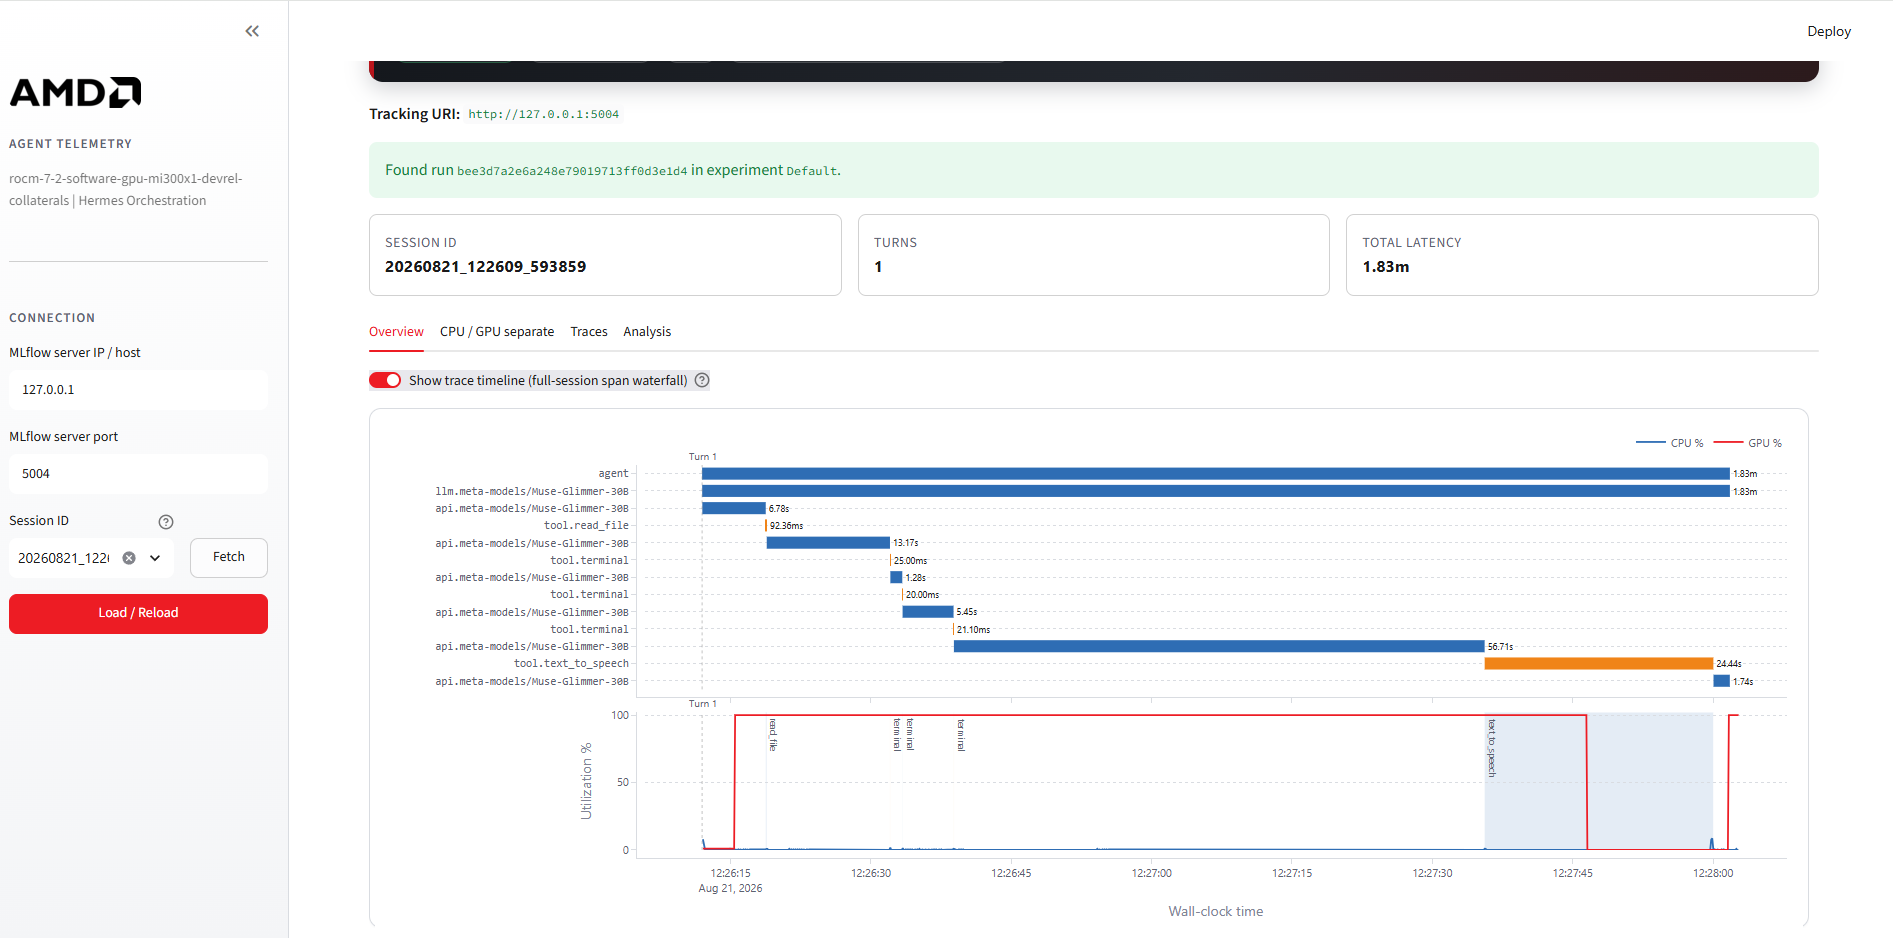" width="96%">
</p>

<p align="center"><sub><i>The Overview tab of the telemetry dashboard. The orange text_to_speech span is the longest single step, and the utilization chart shows the GPU is mostly idle while it runs. That gap is exactly the bottleneck we will fix.</i></sub></p>

<details>
<summary><b>How this works under the hood</b></summary>

<br>

These diagnostics come directly from the MLflow trace. The dashboard parses the raw
OTLP trace JSONs and compiles them into a clean, human-readable summary.

</details>


### Edge TTS observations

In the telemetry dashboard, find the Hermes session id for the Edge TTS run you
just did, then look at the audio Edge produced and note a few things:

- **No local setup.** Edge is cloud-based. Hermes sends text to the service and
  receives audio back, which makes it a convenient baseline: nothing to install,
  nothing to configure.
- **Input-length limit.** Edge TTS has a **5,000-character input limit**. The
  Hermes wrapper handles longer inputs by splitting them into chunks (a
  10K-character input becomes two chunks, and so on, depending on the chunking
  logic).
- **Audio stitching.** The chunks are normally combined into one output, but for
  very large inputs they may not stitch correctly, producing several audio files
  for a single request.
- **Short inputs.** For shorter inputs, Edge TTS works well and is convenient.
- **Privacy.** Because Edge is cloud-based, the text leaves the local machine for
  processing. For privacy-sensitive workloads, a local model is preferable.

> **Why this step can produce messy, repeated tool calls.** The built-in
> `text_to_speech` tool accepts text only *inline* (there is no file-path
> parameter). For a long passage the agent cannot pass the whole text in one call,
> so it often improvises with extra steps (chunked file reads, `wc`/`head`/`cat`,
> temporary copies, small Python snippets) while working around the limit.

The length limit, the stitching edge cases, the privacy consideration and the
network round-trip on every request are together our reason to move to a local
model next.


---

## Step 4 &middot; Local TTS with Kokoro

**Kokoro** is a text-to-speech model that runs entirely on the local machine. Here
it is served by the Kokoro TTS server that `utils/helper.sh` started for you on an **AMD
Instinct&trade; MI300X GPU**.

The server is a lightweight FastAPI + Uvicorn wrapper around the Kokoro model. The
wrapper keeps the model resident in GPU memory between requests, so each synthesis
call is fast instead of paying model-load overhead every time.

Because inference happens locally, your text never leaves the system, a natural fit
for privacy-sensitive workloads. It also means run speed now depends on how well the
tool uses the local hardware, which is exactly what we want to profile.


### The custom tool: `kokoro_tts`

`kokoro_tts` is a custom tool we added to Hermes. It sends text to the local Kokoro
server and returns spoken audio as a **WAV** file (uncompressed, so it preserves the
original quality). Extending Hermes with your own tools and skills is one of its
strengths, and `kokoro_tts` is exactly that: a local text-to-speech tool.

The cell below installs the tool into Hermes. It must live **inside the Hermes
`tools` package**, because the file does `from tools.registry import ...`. Copying
it anywhere else (`~/.hermes/tools/`, for example) looks plausible but leaves the
tool unimportable, and the agent then loops without ever calling it, with no error
message to explain why. The cell locates the real package and verifies the tool
registers, rather than assuming the copy worked.


In [3]:
%%bash
set -uo pipefail

SRC="./custom_tools/kokoro_tts_tool.py"
if [ ! -f "$SRC" ]; then
    echo "[ERROR] $SRC not found. Run this from the repository root."
    exit 1
fi

# Resolve the Hermes installation, whichever layout this machine uses:
# a per-user install (~/.hermes/hermes-agent) or a system one (/usr/local).
# Require BOTH tools/ and venv/bin/python: the verification step below runs
# that interpreter, so a root with tools/ but no venv/ would be selected here
# and then fail on the next command with a confusing "no such file" error.
HERMES_ROOT=""
for cand in "$HOME/.hermes/hermes-agent" /usr/local/lib/hermes-agent; do
    if [ -x "$cand/venv/bin/python" ] && [ -d "$cand/tools" ]; then
        HERMES_ROOT="$cand"
        break
    fi
done

if [ -z "$HERMES_ROOT" ]; then
    echo "[ERROR] Could not find a complete Hermes install (tools/ + venv/)."
    echo "        Has hermes finished installing?"
    exit 1
fi

echo "[INFO] Deploying custom Kokoro TTS tool to $HERMES_ROOT/tools ..."
cp "$SRC" "$HERMES_ROOT/tools/"
echo "[OK] Copied kokoro_tts_tool.py -> $HERMES_ROOT/tools/"

# Prove the tool actually registers. A successful copy is not proof the agent
# can call it.
"$HERMES_ROOT/venv/bin/python" -c "
import sys; sys.path.insert(0, '$HERMES_ROOT')
from tools.registry import registry
import tools.kokoro_tts_tool
names = getattr(registry, 'tools', None) or getattr(registry, '_tools', {})
assert 'kokoro_tts' in names, f'kokoro_tts NOT registered; found {sorted(names)}'
print('[OK] kokoro_tts is registered and callable by the agent.')
"


[INFO] Deploying custom Kokoro TTS tool to /home/amd/.hermes/hermes-agent/tools ...
[OK] Copied kokoro_tts_tool.py -> /home/amd/.hermes/hermes-agent/tools/
[OK] kokoro_tts is registered and callable by the agent.


**Parameters of the `kokoro_tts` tool**

| Parameter | Purpose |
| :--- | :--- |
| `text` | The full text to synthesize, in one call. |
| `text_file` | Path to a UTF-8 file to synthesize. Preferred for long text, so the agent passes a path instead of inlining the whole passage. |
| `mode` | The inference strategy, `sequential` or `batched`. `sequential` is the native Kokoro baseline; `batched` is the optimization we add in Step 5. This parameter is what lets us compare the two. Defaults to `sequential`. |
| `voice` | Voice name (default `af_heart`). |
| `batch_size` | Sentences per GPU forward pass when `mode` is `batched` (default `16`). Ignored in `sequential` mode. |
| `output_path` | Where to save the WAV (defaults to `~/.hermes/audio_cache/`). |

The tool is defined in `custom_tools/kokoro_tts_tool.py` and backed by
`utils/kokoro_server.py`. Let's run it on our input and profile how it performs.


In [4]:
!hermes chat --yolo -q "Use the kokoro_tts tool and pass the file path 'input_text.txt' as the text_file parameter to convert the text to speech. Do not read the file yourself"

Query: Use the kokoro_tts tool and pass the file path 'input_text.txt' as the 
text_file parameter to convert the text to speech. Do not read the file yourself
Initializing agent...
[hermes-otel] ✓ mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] ✓ Live dashboard store active
[hermes-otel] Registered 13 hooks
────────────────────────────────────────

  ┊ ⚡ preparing tool_describe…
  ┊ ⚡ tool_desc kokoro_tts  0.1s
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ kokoro_tt   106.1s
  (tip) That tool ran for a while. Use /verbose to cycle tool-progress display modes (all -> new -> off -> verbose). This tip only shows once.

╭─ ⚕ Hermes ───────────────────────────────────────────────────────────────────╮
The Kokoro TTS conversion is complete.

Output audio: /home/amd/.hermes/audio_cache/kokoro_tts_sequential_20260821_123251.wav

Details: 63 sentences processed in 105.76 s inference, 612.0 s of audio (5.8× real-time), mode sequential.
╰───────────────────────

### How `kokoro_tts` works, and why the first run is slow

`kokoro_tts` runs the Kokoro TTS model locally on the AMD MI300X GPU. In its default
mode it processes the input **one sentence at a time** and saves the result as a WAV
file.

Load this run in the dashboard the same way as before: click **Fetch**, select
the run at the top of the list, then click **Load / Reload**. You should see:

- The **`kokoro_tts`** span occupies the largest part of the timeline, so it is the
  primary contributor to end-to-end latency.
- **GPU utilization stays low for most of the run.** The MI300X is not being fully
  used.
- Because sentences are processed one at a time, each inference gives the GPU only a
  small amount of work, which is inefficient.
- As the number of sentences grows, the tool runs more inference passes, so latency
  grows **almost linearly**.

> The tool works and produces correct audio, but it clearly under-uses the GPU.
> That is the bottleneck the dashboard reveals, and the motivation to optimize the
> tool next.


---

## Step 5 &middot; Optimize the tool with batching

The dashboard showed the bottleneck: the tool feeds the GPU **one sentence at a
time**. So we edited `kokoro_tts` to add an optimized **`batched`** mode.

Instead of processing text one piece at a time (the original behavior, which we now
call **`sequential`** mode), the new **`batched`** mode groups many sentences and
sends them to the GPU in a single forward pass, giving the hardware much more work to
do at once.


<p align="center">
<img alt="Comparison of sequential and batched processing. In sequential mode five sentences s1 to s5 each take their own forward pass, causing five GPU launches and low utilization. In batched mode the same five sentences are grouped and length-bucketed into a single GPU launch with high utilization." src="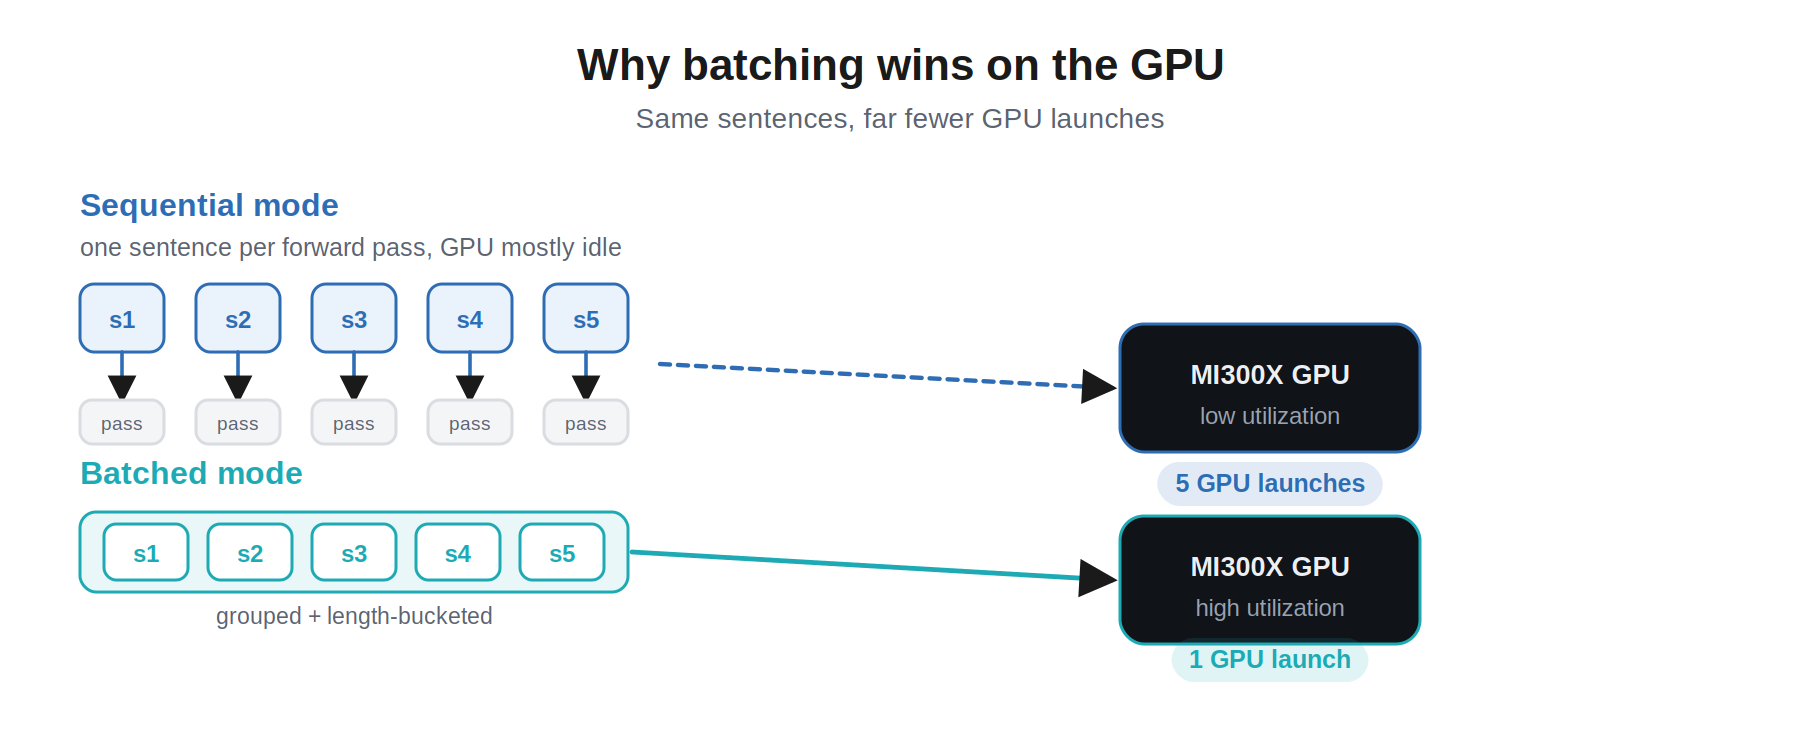" width="94%">
</p>

<p align="center"><sub><i>Sequential mode issues one GPU launch per sentence; batched mode groups them into a single launch, keeping the GPU busy.</i></sub></p>

We re-run the exact same input, this time asking for `mode='batched'`, and
compare.


In [5]:
!hermes chat --yolo -q "Use the kokoro_tts tool with the mode parameter set to 'batched', and pass the file path 'input_text.txt' as the text_file parameter. Do not read the file yourself"

Query: Use the kokoro_tts tool with the mode parameter set to 'batched', and 
pass the file path 'input_text.txt' as the text_file parameter. Do not read the 
file yourself
Initializing agent...
[hermes-otel] ✓ mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] ✓ Live dashboard store active
[hermes-otel] Registered 13 hooks
────────────────────────────────────────

  ┊ ⚡ preparing tool_describe…
  ┊ ⚡ tool_desc kokoro_tts  0.0s
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ kokoro_tt   9.7s

╭─ ⚕ Hermes ───────────────────────────────────────────────────────────────────╮
Done. Audio saved to /home/amd/.hermes/audio_cache/kokoro_tts_batched_20260821_123419.wav (batched mode, 63 sentences, 9.35 s inference).
╰──────────────────────────────────────────────────────────────────────────────╯

Resume this session with:
  hermes --resume 20260821_123330_1d1998
  hermes -c "Run kokoro_tts batched on input_text.txt"

Session:        20260821_123330_1d1998
Title:  

Load this run in the dashboard the same way as before: click **Fetch**, select
this run (it appears at the top), then click **Load / Reload**. Then compare it
side by side with the sequential run.

### What changed under the hood

`mode='batched'` uses our optimized implementation. Kokoro does not support native
batching, so we modified the inference pipeline to process multiple sentences in a
single GPU forward pass instead of one at a time:

- **Batching.** Multiple sentences are grouped so the GPU processes more work per
  forward pass, improving hardware utilization.
- **Length bucketing.** Sentences of similar length are grouped into the same batch,
  reducing wasted padding.
- **Correct batched processing.** Padding and attention masks keep each sentence
  independent, and the final audio is trimmed back to its true length. See
  `utils/kokoro_server.py` for the source code.

### What you should see in the dashboard

- With `mode='batched'`, `kokoro_tts` completes **significantly faster** than
  sequential.
- The GPU does **more work per forward pass**, so utilization is higher and overhead
  is lower.
- Fewer GPU launches overall, because sentences are processed together rather than
  one at a time.
- CPU activity stays relatively low, confirming the workload is GPU-bound during
  synthesis.
- The audio output is **the same**; only the execution time drops.

> **Takeaway.** Batching improves throughput and GPU utilization, which makes it the
> preferred mode for longer inputs.


---

## Step 6 &middot; Visualize the improvement

A picture makes the whole journey obvious. Tool execution time matters across **all
three approaches**, not just sequential vs batched. Moving from cloud **Edge TTS** to
the **local Kokoro** model, and then to **batched** Kokoro, overcomes Edge's
drawbacks and delivers strong execution time entirely on local hardware.


<p align="center">
<img alt="Three approaches compared as cards. Edge TTS is the cloud baseline with zero setup, a 5,000-character cap and text leaving the machine. Kokoro sequential is the local baseline, one sentence per GPU pass, correct but under-using the GPU. Kokoro batched is the local optimized approach with many sentences per GPU pass, length bucketing and masks, same audio at far higher throughput." src="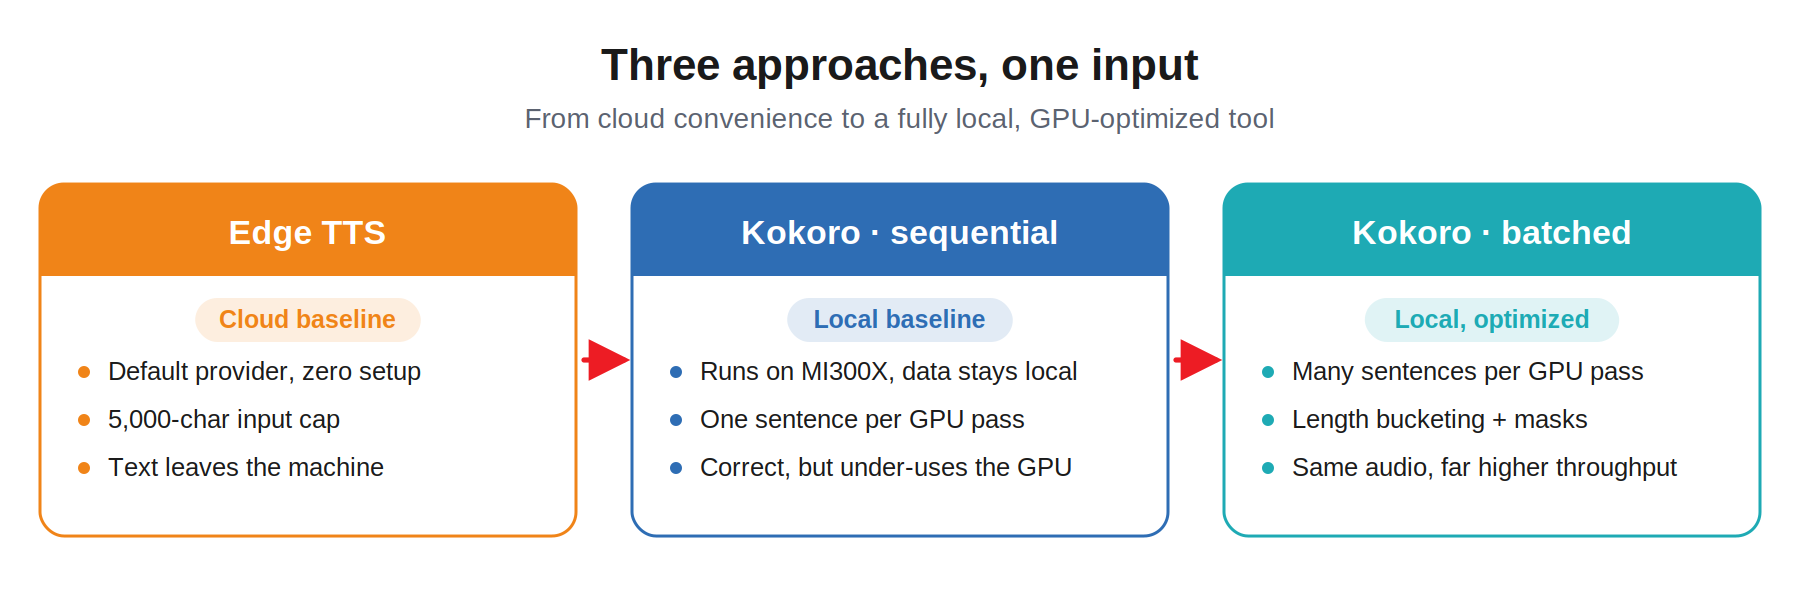" width="94%">
</p>

<p align="center"><sub><i>The three approaches, from cloud convenience to a fully local, GPU-optimized tool.</i></sub></p>

The cell below uses **Matplotlib** to plot the **tool execution time** of the
three approaches side by side, so the cloud-to-local move and the
sequential-to-batched optimization show up in a single view.

> **Use your own numbers.** `edge_time`, `seq_time` and `batched_time` are
> pre-filled with the values measured on the MI300X workshop machine, so the chart
> renders meaningfully before you run anything. Replace them with the **execution
> seconds** from your own runs (each tool's output line and the profiling
> dashboard). Note that for long text Edge **truncates** its output, so its time is
> shown to give context for the cloud baseline rather than as a like-for-like
> comparison.


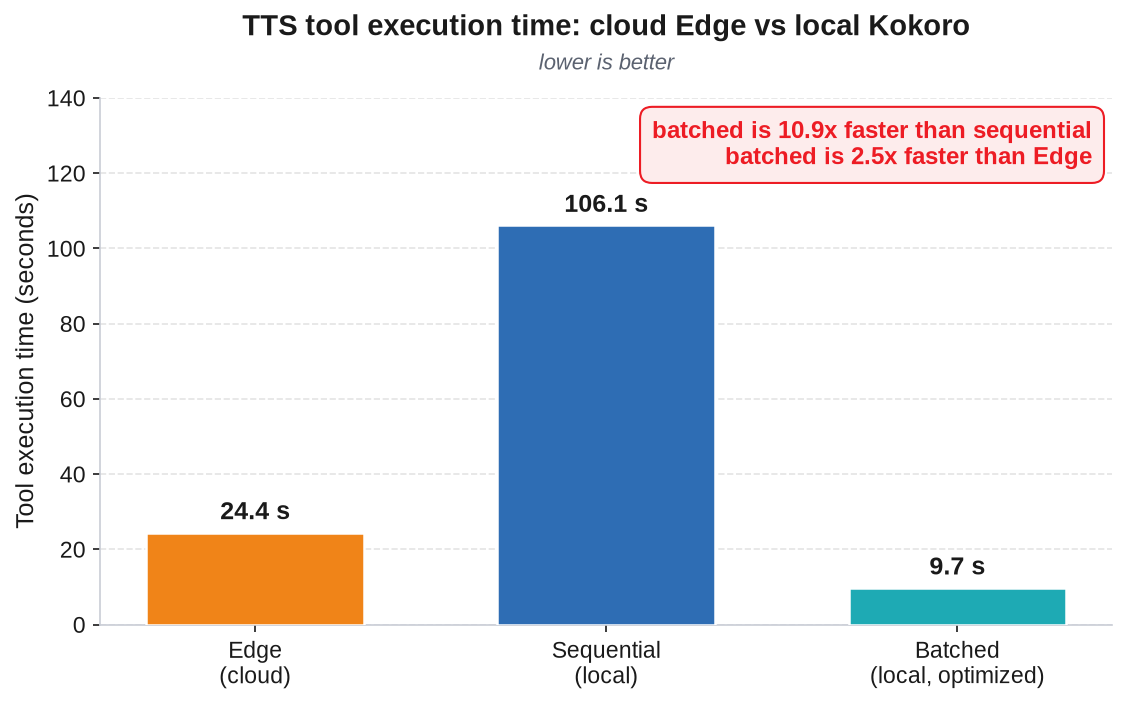

Edge: 24.4s | Sequential: 106.1s | Batched: 9.7s


In [6]:
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager

# --- Tool execution time (seconds) for each approach ---
# Defaults are the numbers measured on the MI300X workshop machine on
# 2026-08-21, for the ~8,450-character passage this notebook generates. They
# are the same run that tts_executed.ipynb captures. Replace them with the
# execution seconds from your OWN runs, taken from each tool's output line and
# the profiling dashboard.
edge_time = 24.4      # Edge TTS (cloud) - note: truncates long text (~5 min cap)
seq_time = 106.1      # Kokoro, sequential mode (local, unoptimized)
batched_time = 9.7    # Kokoro, batched mode (local, optimized)

# --- AMD look and feel -------------------------------------------------------
# Arial-metric font (Liberation Sans) so the chart matches the AMD web family,
# with a graceful fallback to whatever sans-serif is installed.
for _f in ("Arial", "Liberation Sans", "DejaVu Sans"):
    if any(_f in f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break

AMD_RED = "#ED1C24"
INK     = "#1A1A1A"
SUBINK  = "#5B6270"
EDGE_C  = "#F08418"   # cloud Edge (dashboard orange)
SEQ_C   = "#2E6DB4"   # local sequential (dashboard blue)
BATCH_C = "#1EAAB4"   # local batched (teal)

labels = ["Edge\n(cloud)", "Sequential\n(local)", "Batched\n(local, optimized)"]
times  = [edge_time, seq_time, batched_time]
colors = [EDGE_C, SEQ_C, BATCH_C]

fig, ax = plt.subplots(figsize=(7.6, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(labels, times, color=colors, width=0.62, zorder=3,
              edgecolor="white", linewidth=1.2)
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
ax.set_ylabel("Tool execution time (seconds)", fontsize=12, color=INK)
ax.set_title("TTS tool execution time: cloud Edge vs local Kokoro",
             fontsize=14, fontweight="bold", color=INK, pad=30)
ax.text(0.5, 1.045, "lower is better", transform=ax.transAxes, ha="center",
        va="bottom", fontsize=10.5, color=SUBINK, style="italic")
ax.set_ylim(0, max(times) * 1.32)
ax.bar_label(bars, fmt="%.1f s", padding=4, fontweight="bold",
             fontsize=12, color=INK)
ax.tick_params(colors=INK, labelsize=11)

notes = []
if seq_time and batched_time:
    notes.append(f"batched is {seq_time / batched_time:.1f}x faster than sequential")
if edge_time and batched_time:
    notes.append(f"batched is {edge_time / batched_time:.1f}x faster than Edge")
if notes:
    ax.text(0.98, 0.96, "\n".join(notes), transform=ax.transAxes,
            ha="right", va="top", fontsize=11.5, fontweight="bold",
            color=AMD_RED,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#FDECEC",
                      edgecolor=AMD_RED, linewidth=1.0))

for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#C9CDD6")

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/tts_execution_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

print(f"Edge: {edge_time:.1f}s | Sequential: {seq_time:.1f}s | "
      f"Batched: {batched_time:.1f}s")

---

## The loop, applied to anything

You have now run the full loop on one example. The same **observability-driven**
workflow applies far beyond TTS.


<p align="center">
<img alt="The observability-driven loop as five numbered steps: 1 Run the agent, 2 Fetch in the dashboard, 3 Inspect spans and GPU, 4 Optimize the slow tool, 5 Measure again, with a dashed arrow looping back to step 1 to repeat until the bottleneck is gone." src="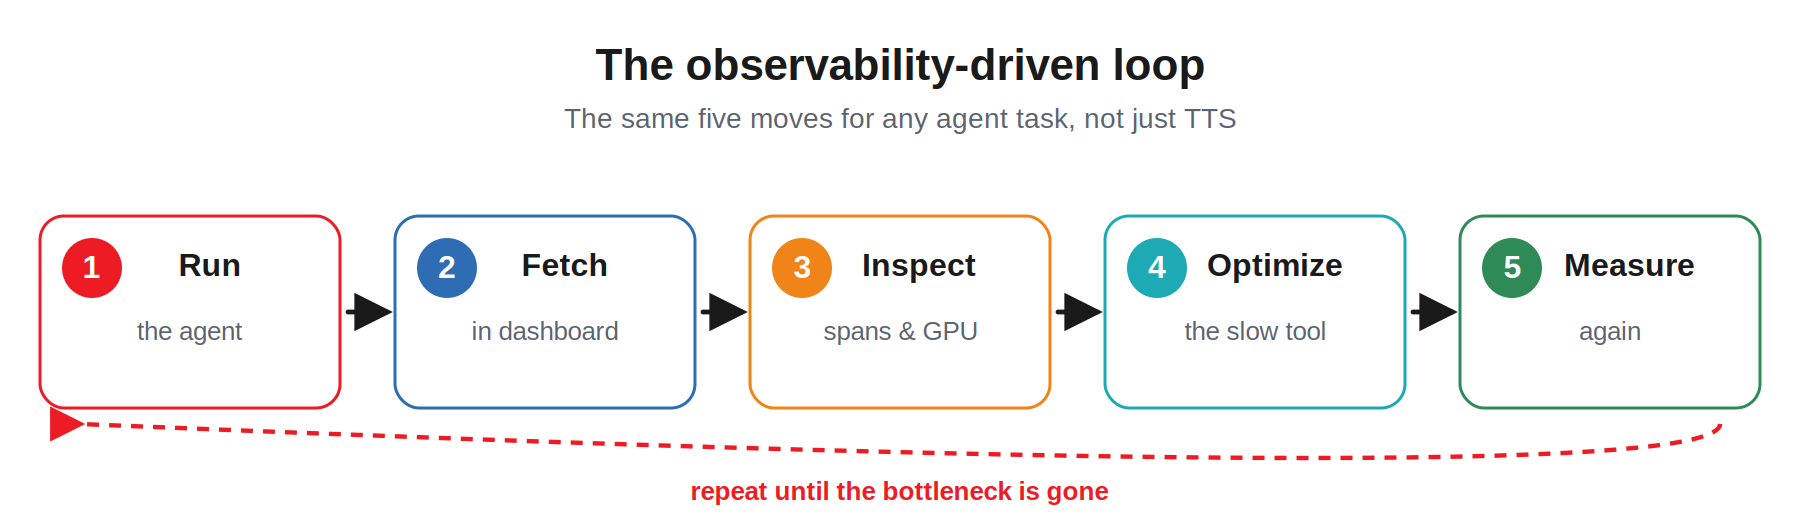" width="92%">
</p>

<p align="center"><sub><i>The same five moves work for any agent task, not just text-to-speech.</i></sub></p>

**Try different inputs for this TTS example**

1. Regenerate `input_text.txt` by rerunning the *Prepare your input text* cell with
   a new topic, or edit the file directly. Longer, multi-sentence text makes the
   batched speed-up more obvious.
2. Re-run the two synthesis cells: `kokoro_tts` in the default (sequential) mode,
   then with `mode='batched'`.
3. In the dashboard, click **Fetch**, select the latest run for each and click
   **Load / Reload**, then update the Matplotlib cell with your own execution
   times to compare.

> **Re-running the Edge baseline.** Once `kokoro_tts` is installed, the agent will
> normally prefer it, so the Edge cell no longer measures Edge. To get a genuine
> Edge run again, remove the custom tool first, then re-run the Step 1 cell:
>
> ```bash
> rm -f ~/.hermes/hermes-agent/tools/kokoro_tts_tool.py       # per-user install
> rm -f /usr/local/lib/hermes-agent/tools/kokoro_tts_tool.py  # container image
> ```
>
> Re-run the *custom tool* install cell above to put it back.

**Try it on your own use cases**

Text-to-speech was only the example. Point the same workflow at *any* Hermes task, a
research query, a coding task, a multi-tool workflow, and:

- **Profile the run** in the dashboard (click **Fetch**, select the run, then
  **Load / Reload**) to see the CPU/GPU timeline and which tool dominated.
- **Inspect the MLflow traces** (the **Traces** view) to drill into each session,
  LLM call, and tool call and see exactly where the time went.
- **Find the bottleneck, optimize it, and measure again**, the same loop you just
  followed here.

> **Tip.** The bigger the workload, the clearer the wins. Let the dashboard and
> traces point you to the slow step instead of guessing.


---

## Conclusion and key takeaways

This exercise walked through an observability-driven optimization workflow: we
compared cloud-based Edge TTS with a local Kokoro model, identified the bottleneck
through telemetry, optimized the local implementation, and measured the improvement.

| Phase | Tool | Execution | Outcome |
| :--- | :--- | :--- | :--- |
| **1 &middot; Edge TTS** | `text_to_speech` | Cloud-based | Convenient for short inputs, but sends text off-machine and leaves room to reduce execution time. |
| **2 &middot; Kokoro, sequential** | `kokoro_tts` | Local MI300X, one sentence/pass | Complete output, but slower with low GPU utilization. |
| **3 &middot; Kokoro, batched** | `kokoro_tts` (`mode='batched'`) | Local MI300X, many sentences/pass | Same output, significantly better execution time and GPU utilization. |

### What we learned

- **Cloud to local.** Moving from Edge TTS to a local Kokoro model removed the
  input-length limit and kept text processing on the machine.
- **Establish a baseline.** The sequential Kokoro implementation gave us a baseline
  for local TTS performance.
- **Measure, do not guess.** The observability dashboard made it clear that the
  local model was under-using the GPU.
- **Optimize with batching.** A batched mode processes multiple sentences together,
  cutting inference and launch overhead and using the GPU better.
- **Validate the improvement.** Re-running confirmed batched Kokoro beat sequential
  by a wide margin and improved on Edge.
- **Iterate.** Switch to a local model, establish a baseline, find the bottleneck,
  optimize, and measure again.

### Handy extras

- **Raw MLflow UI (advanced).** Browse everything directly at
  `http://<server-ip>:5004`, under the **Traces** and **Runs** tabs.
- **Analysis tab.** Click *Analyze with Hermes* in the dashboard for automatic,
  plain-language suggestions based on the run's `tool_breakdown.csv`.

<details>
<summary><b>Additional information: understanding the kernel cache</b></summary>

<br>

For a specific input using Kokoro:

- **First run (cold run).** The first execution compiles the required GPU kernels.
  This compilation overhead increases execution time.
- **Subsequent runs.** From the second run onward, compiled kernels are reused from
  the cache, giving faster execution and lower latency.
- **Clearing the cache.** For Python-based executions, the kernel cache can be
  cleared with `utils/clear_cache.sh`. In this workshop, however, Kokoro runs as a
  persistent server, so clearing the cache means stopping the server, deleting the
  cache, and restarting before benchmarking again.

**How does the cache work?**

MIOpen stores compiled and tuned GPU kernels in its cache. With
`MIOPEN_FIND_MODE=FAST`, MIOpen skips the expensive kernel search on later runs and
reuses the best cached kernel. COMGR caches the LLVM compilation artifacts, avoiding
recompilation of GPU code on future executions.

**Is the cache reused for every input?**

Not always. The cache is built for specific kernel configurations that depend on
factors such as input shape (sequence length, tensor dimensions). If a new input
needs a configuration that has not been compiled before, MIOpen compiles and caches
it during that execution. Once cached, later runs with the same configuration reuse
it.

</details>
